# WTI Managed Money — Lead/Lag Analysis with F1-F2 Spread

Does MM positioning lead price, or does price lead MM positioning?

- **COT**: WTI-Physical disaggregated combined (weekly, joined on release date)
- **Prices**: WTI daily rolled prices (Friday close to match release date)
- All correlations use Spearman (rank-based, robust to outliers)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.append('../../../../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load COT data

In [2]:
COT_PATH = '/Users/oualid/Documents/Projects/omroot_repos/cftc_data/cftc_downloads/disaggregated_combined.csv'

raw = pd.read_csv(COT_PATH, low_memory=False)
# WTI requires combining two contracts:
#   067651 = WTI-PHYSICAL (NYMEX)
#   067411 = CRUDE OIL, LIGHT SWEET-WTI (ICE, listed on NYMEX)
WTI_CODES = ['067651', '067411']
wti_raw = raw[raw['cftc_contract_market_code'].isin(WTI_CODES)].copy()
wti_raw['as_of_date'] = pd.to_datetime(wti_raw['report_date_as_yyyy_mm_dd'])

_SUM_COLS = [
    'open_interest_all',
    'prod_merc_positions_long', 'prod_merc_positions_short',
    'swap_positions_long_all', 'swap__positions_short_all',
    'm_money_positions_long_all', 'm_money_positions_short_all',
    'other_rept_positions_long', 'other_rept_positions_short',
    'nonrept_positions_long_all', 'nonrept_positions_short_all',
]
for c in _SUM_COLS:
    wti_raw[c] = pd.to_numeric(wti_raw[c], errors='coerce')

wti = wti_raw.groupby('as_of_date')[_SUM_COLS].sum().reset_index()

days_ahead = (4 - wti['as_of_date'].dt.dayofweek) % 7
wti['release_date'] = wti['as_of_date'] + pd.to_timedelta(days_ahead, unit='D')
wti['open_interest'] = pd.to_numeric(wti['open_interest_all'], errors='coerce')

# MM positioning
wti['mm_long']  = pd.to_numeric(wti['m_money_positions_long_all'], errors='coerce')
wti['mm_short'] = pd.to_numeric(wti['m_money_positions_short_all'], errors='coerce')
wti['mm_net']   = wti['mm_long'] - wti['mm_short']
wti['mm_net_oi'] = wti['mm_net'] / wti['open_interest'] * 100

wti.sort_values('as_of_date', inplace=True)
wti.reset_index(drop=True, inplace=True)

cot = wti[['as_of_date', 
           'release_date', 
           'mm_net', 
           'mm_long', 
           'mm_short',
           'mm_net_oi', 
           'open_interest']].copy()

print(f'COT rows: {len(cot)}')
print(f'COT range: {cot["as_of_date"].min().date()} -> {cot["as_of_date"].max().date()}')
print(f'Missing mm_net: {cot["mm_net"].isna().sum()}')
print(f'Missing OI: {cot["open_interest"].isna().sum()}')

COT rows: 1033
COT range: 2006-06-13 -> 2026-03-24
Missing mm_net: 0
Missing OI: 0


## 2. Load price data

In [3]:
prices = pd.read_csv('../../../../cache/preprocessed_data/wti_prices_panel.csv',
                      usecols=['tradeDate', 'F1MinusF2_RolledPrice'])
prices['tradeDate'] = pd.to_datetime(prices['tradeDate'])
prices.sort_values('tradeDate', inplace=True)
prices.reset_index(drop=True, inplace=True)

print(f'Price rows: {len(prices)}')
print(f'Price range: {prices["tradeDate"].min().date()} -> {prices["tradeDate"].max().date()}')
print(f'Missing F1MinusF2_RolledPrice: {prices["F1MinusF2_RolledPrice"].isna().sum()}')

Price rows: 3921
Price range: 2010-01-04 -> 2025-08-05
Missing F1MinusF2_RolledPrice: 0


## 3. Join on release date

Match each COT release Friday to the closest daily price row (also Friday,
or the prior business day if Friday is a holiday).

In [4]:
# merge_asof: find the closest price on or before each release_date
cot_sorted = cot.sort_values('as_of_date').copy()

df = pd.merge_asof(
    cot_sorted,
    prices.rename(columns={'tradeDate': 'as_of_date'}),
    on='as_of_date',
    direction='backward',
    tolerance=pd.Timedelta(days=3),  # max 3 days back (handles holidays)
)

print(f'Joined rows: {len(df)}')
print(f'Missing price after join: {df["F1MinusF2_RolledPrice"].isna().sum()}')
print(f'Overlap range: {df["as_of_date"].min().date()} -> {df["as_of_date"].max().date()}')

# Drop rows with missing data
before = len(df)
df.dropna(subset=['mm_net', 'F1MinusF2_RolledPrice', 'open_interest'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'After dropna: {len(df)} rows (dropped {before - len(df)})')

Joined rows: 1033
Missing price after join: 220
Overlap range: 2006-06-13 -> 2026-03-24
After dropna: 813 rows (dropped 220)


## 4. Compute weekly changes

In [5]:
df.sort_values('as_of_date', inplace=True)
df.reset_index(drop=True, inplace=True)

# Weekly changes
df['mm_net_chg']    = df['mm_net'].diff()
df['mm_net_oi_chg'] = df['mm_net_oi'].diff()
df['spread_ret']     = df['F1MinusF2_RolledPrice'].pct_change() * 100  # weekly % return

# Drop first row (no prior for diff)
df = df.iloc[1:].reset_index(drop=True)

print(f'Clean weekly rows: {len(df)}')
print(f'Missing mm_net_chg: {df["mm_net_chg"].isna().sum()}')
print(f'Missing spread_ret: {df["spread_ret"].isna().sum()}')
print()
print(df[['as_of_date', 'release_date', 'mm_net_chg', 'mm_net_oi_chg', 'spread_ret']].describe().round(3))

Clean weekly rows: 812
Missing mm_net_chg: 0
Missing spread_ret: 0

                          as_of_date                   release_date  \
count                            812                            812   
mean   2017-10-26 05:35:10.344827648  2017-10-29 05:47:35.172413696   
min              2010-01-12 00:00:00            2010-01-15 00:00:00   
25%              2013-12-08 06:00:00            2013-12-11 06:00:00   
50%              2017-10-27 12:00:00            2017-10-30 12:00:00   
75%              2021-09-15 18:00:00            2021-09-18 18:00:00   
max              2025-08-05 00:00:00            2025-08-08 00:00:00   
std                              NaN                            NaN   

       mm_net_chg  mm_net_oi_chg  spread_ret  
count     812.000        812.000     812.000  
mean     -203.451         -0.007       1.308  
min   -105378.000         -3.059    -800.000  
25%    -16010.500         -0.485      -1.017  
50%       548.500         -0.026      -0.000  
75%     15

## 5. Contemporaneous correlation

Same-week: does the MM net change from Tue(t-1) to Tue(t)
correlate with the spread return over roughly the same period?

In [6]:
rho_raw, p_raw = sp_stats.spearmanr(df['mm_net_chg'], df['spread_ret'])
rho_oi, p_oi   = sp_stats.spearmanr(df['mm_net_oi_chg'], df['spread_ret'])

print(f'Contemporaneous (same week):')
print(f'  MM net change vs spread return:    rho = {rho_raw:+.3f}  (p = {p_raw:.1e})')
print(f'  MM net/OI change vs spread return: rho = {rho_oi:+.3f}  (p = {p_oi:.1e})')

Contemporaneous (same week):
  MM net change vs spread return:    rho = +0.291  (p = 2.4e-17)
  MM net/OI change vs spread return: rho = +0.287  (p = 7.4e-17)


## 6. Cross-correlation function (CCF)

- **Positive lag**: MM change this week vs spread return in future weeks (MM leads spread)
- **Negative lag**: spread return this week vs MM change in future weeks (spread leads MM)

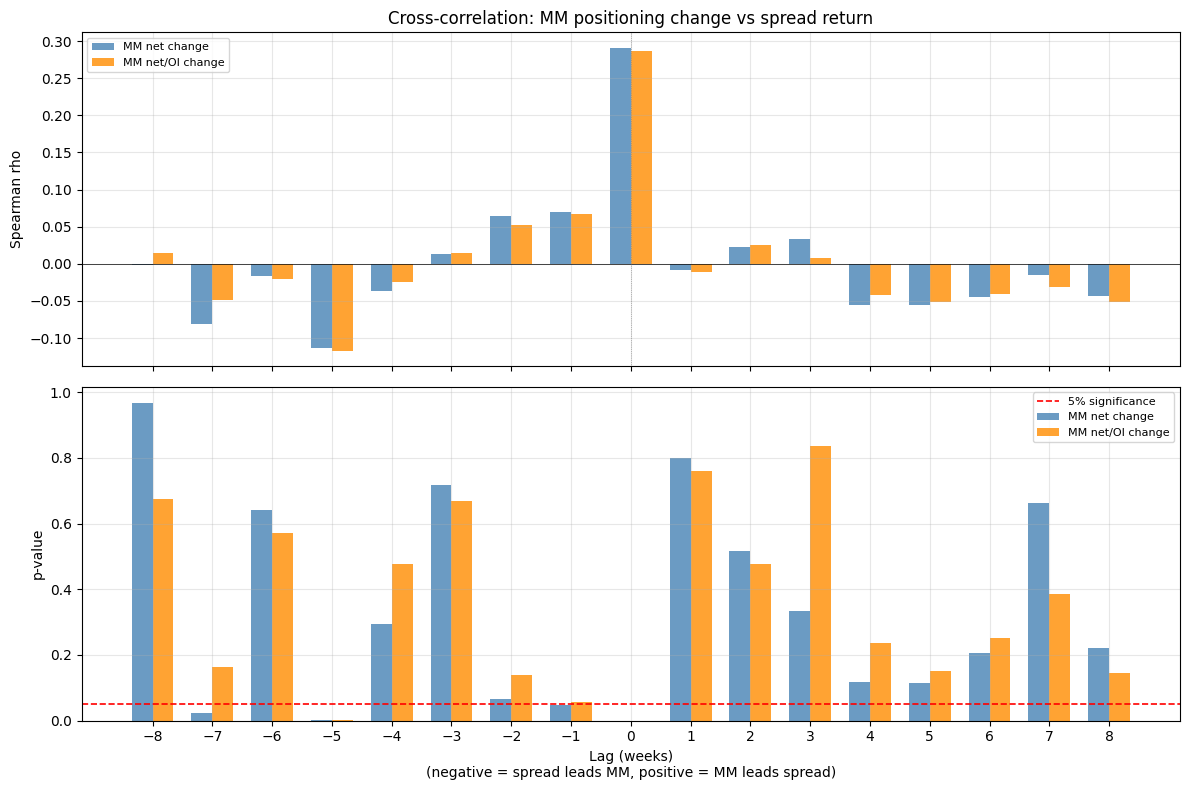

 Lag   rho (raw)       p-val    rho (OI)       p-val  Interpretation
-------------------------------------------------------------------------------------
  -8     -0.001       9.7e-01     +0.015       6.8e-01  spread leads MM by 8w
  -7     -0.081 *     2.2e-02     -0.049       1.6e-01  spread leads MM by 7w
  -6     -0.016       6.4e-01     -0.020       5.7e-01  spread leads MM by 6w
  -5     -0.114 *     1.2e-03     -0.117 *     8.5e-04  spread leads MM by 5w
  -4     -0.037       2.9e-01     -0.025       4.8e-01  spread leads MM by 4w
  -3     +0.013       7.2e-01     +0.015       6.7e-01  spread leads MM by 3w
  -2     +0.065       6.6e-02     +0.052       1.4e-01  spread leads MM by 2w
  -1     +0.069 *     4.9e-02     +0.067       5.7e-02  spread leads MM by 1w
   0     +0.291 *     2.4e-17     +0.287 *     7.4e-17  same week
   1     -0.009       8.0e-01     -0.011       7.6e-01  MM leads spread by 1w
   2     +0.023       5.2e-01     +0.025       4.8e-01  MM leads spread by 2w

In [7]:
MAX_LAG = 8
mm_vals = df['mm_net_chg'].values
mm_oi_vals = df['mm_net_oi_chg'].values
spread_vals = df['spread_ret'].values

def compute_ccf(x, y, max_lag):
    """Spearman cross-correlation at lags -max_lag to +max_lag.
    Positive lag k: corr(x[t], y[t+k]) — x leads y.
    """
    lags = range(-max_lag, max_lag + 1)
    rhos, pvals = [], []
    for k in lags:
        if k >= 0:
            rho, p = sp_stats.spearmanr(x[:len(x)-k], y[k:])
        else:
            rho, p = sp_stats.spearmanr(x[-k:], y[:len(y)+k])
        rhos.append(rho)
        pvals.append(p)
    return list(lags), rhos, pvals

lags, rhos_raw, pvals_raw = compute_ccf(mm_vals, spread_vals, MAX_LAG)
_, rhos_oi, pvals_oi = compute_ccf(mm_oi_vals, spread_vals, MAX_LAG)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
bar_width = 0.35
x_pos = np.array(lags)

# Top panel: Spearman rho
ax = axes[0]
ax.bar(x_pos - bar_width/2, rhos_raw, bar_width, color='steelblue',
       alpha=0.8, label='MM net change')
ax.bar(x_pos + bar_width/2, rhos_oi, bar_width, color='darkorange',
       alpha=0.8, label='MM net/OI change')
ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='grey', lw=0.5, linestyle=':')
ax.set_ylabel('Spearman rho')
ax.set_title('Cross-correlation: WTI MM positioning change vs spread return')
ax.legend(loc='upper left', fontsize=8)

# Bottom panel: p-values
ax = axes[1]
ax.bar(x_pos - bar_width/2, pvals_raw, bar_width, color='steelblue',
       alpha=0.8, label='MM net change')
ax.bar(x_pos + bar_width/2, pvals_oi, bar_width, color='darkorange',
       alpha=0.8, label='MM net/OI change')
ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% significance')
ax.set_ylabel('p-value')
ax.set_xlabel('Lag (weeks)\n'
              '(negative = spread leads MM, positive = MM leads spread)')
ax.set_xticks(lags)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Print table
print(f'{"Lag":>4s}  {"rho (raw)":>10s}  {"p-val":>10s}  {"rho (OI)":>10s}  {"p-val":>10s}  Interpretation')
print('-' * 85)
for k, rr, pr, ro, po in zip(lags, rhos_raw, pvals_raw, rhos_oi, pvals_oi):
    if k < 0:
        interp = f'spread leads MM by {-k}w'
    elif k == 0:
        interp = 'same week'
    else:
        interp = f'MM leads spread by {k}w'
    sig_r = '*' if pr < 0.05 else ' '
    sig_o = '*' if po < 0.05 else ' '
    print(f'{k:>4d}  {rr:>+9.3f} {sig_r}  {pr:>10.1e}  {ro:>+9.3f} {sig_o}  {po:>10.1e}  {interp}')


## 6b. CCF by 5-year blocks

Is the lead/lag structure stable across different market regimes,
or is the full-sample CCF dominated by a particular period?

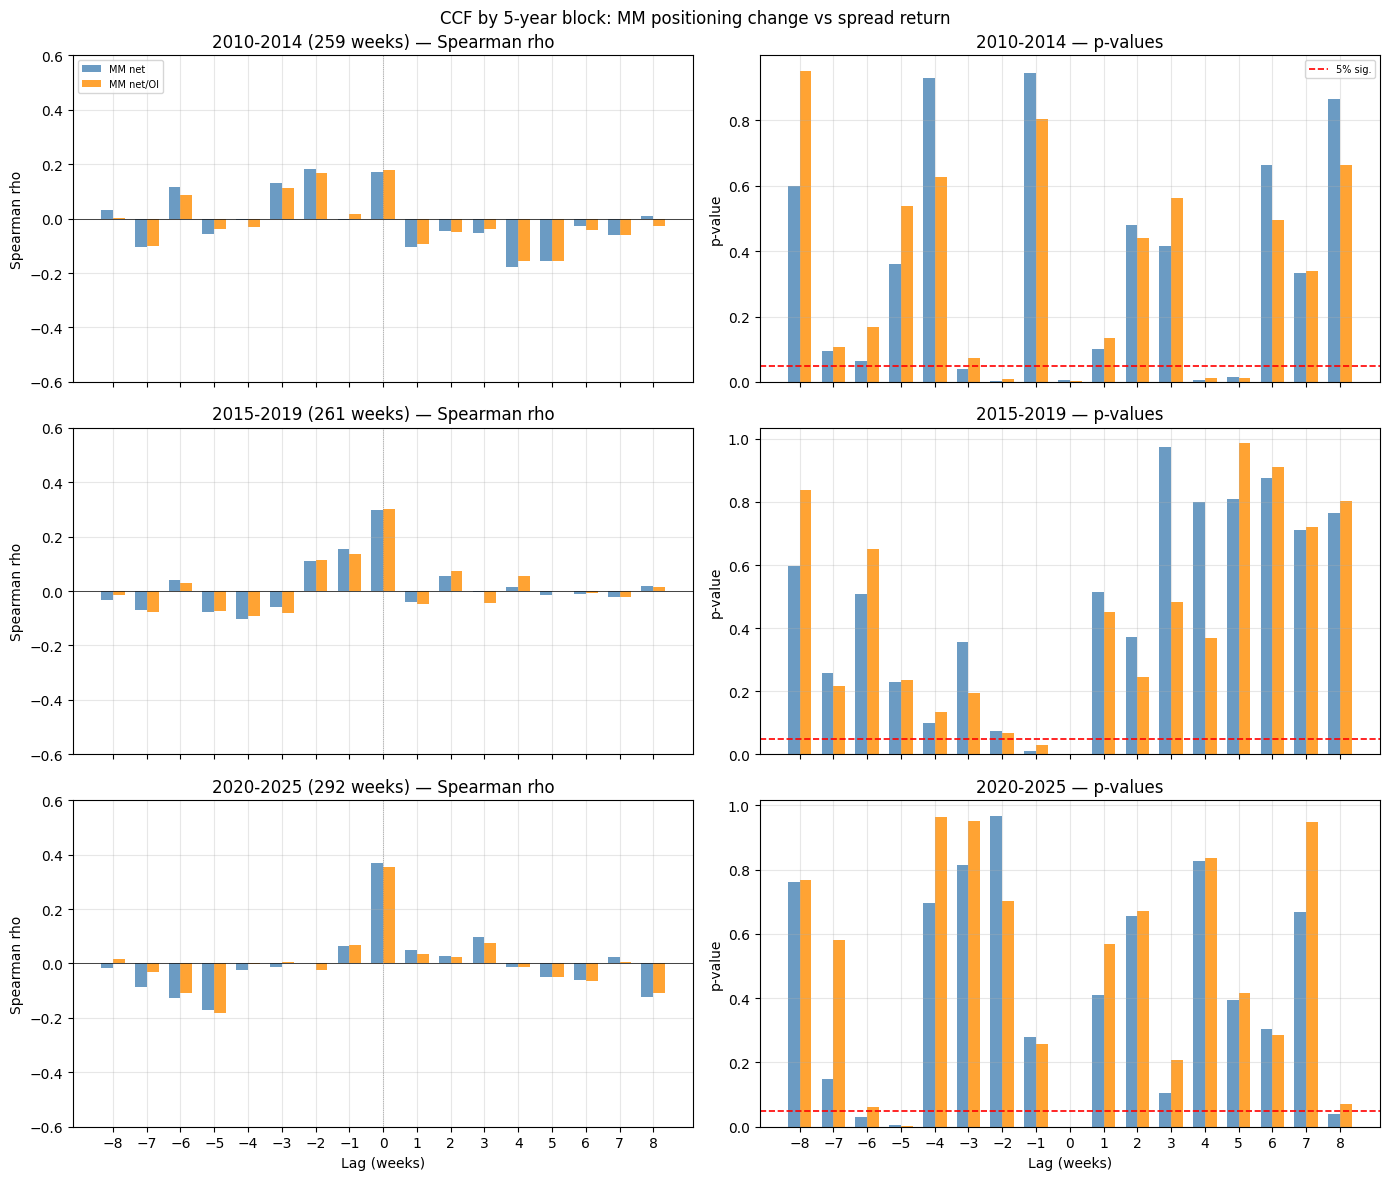

In [8]:
# Define 5-year blocks
df['year'] = df['as_of_date'].dt.year
blocks = [
    ('2010-2014', (2010, 2014)),
    ('2015-2019', (2015, 2019)),
    ('2020-2025', (2020, 2025)),
]

fig, axes = plt.subplots(len(blocks), 2, figsize=(14, 4 * len(blocks)),
                         sharex=True)
bar_width = 0.35

for row, (label, (y_start, y_end)) in enumerate(blocks):
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    mm_oi_b = sub['mm_net_oi_chg'].values
    sp_b = sub['spread_ret'].values

    lags_b, rhos_raw_b, pvals_raw_b = compute_ccf(mm_b, sp_b, MAX_LAG)
    _, rhos_oi_b, pvals_oi_b = compute_ccf(mm_oi_b, sp_b, MAX_LAG)
    x_pos = np.array(lags_b)

    # Rho panel
    ax = axes[row, 0]
    ax.bar(x_pos - bar_width/2, rhos_raw_b, bar_width,
           color='steelblue', alpha=0.8, label='MM net')
    ax.bar(x_pos + bar_width/2, rhos_oi_b, bar_width,
           color='darkorange', alpha=0.8, label='MM net/OI')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5, linestyle=':')
    ax.set_ylabel('Spearman rho')
    ax.set_title(f'{label} ({len(sub)} weeks) — Spearman rho')
    ax.set_ylim(-0.6, 0.6)
    if row == 0:
        ax.legend(fontsize=7, loc='upper left')

    # P-value panel
    ax = axes[row, 1]
    ax.bar(x_pos - bar_width/2, pvals_raw_b, bar_width,
           color='steelblue', alpha=0.8)
    ax.bar(x_pos + bar_width/2, pvals_oi_b, bar_width,
           color='darkorange', alpha=0.8)
    ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
    ax.set_ylabel('p-value')
    ax.set_title(f'{label} — p-values')
    ax.set_xticks(lags_b)
    if row == 0:
        ax.legend(fontsize=7)

axes[-1, 0].set_xlabel('Lag (weeks)')
axes[-1, 1].set_xlabel('Lag (weeks)')
plt.suptitle('CCF by 5-year block: WTI MM positioning change vs spread return',
             fontsize=12)
plt.tight_layout()
plt.show()


In [9]:
# Summary table: key lags by block
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    sp_b = sub['spread_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                sp_b[k:] if k > 0 else sp_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], sp_b[:len(sp_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()


       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2014   259  +0.183  -0.004  +0.170  -0.103  -0.044
   2015-2019   261  +0.112  +0.155  +0.298  -0.041  +0.056
   2020-2025   292  +0.002  +0.064  +0.371  +0.048  +0.026
 Full sample   812  +0.065  +0.069  +0.291  -0.009  +0.023


## 6c. CCF by 3-year blocks

Finer granularity to see how the lead/lag structure evolves.

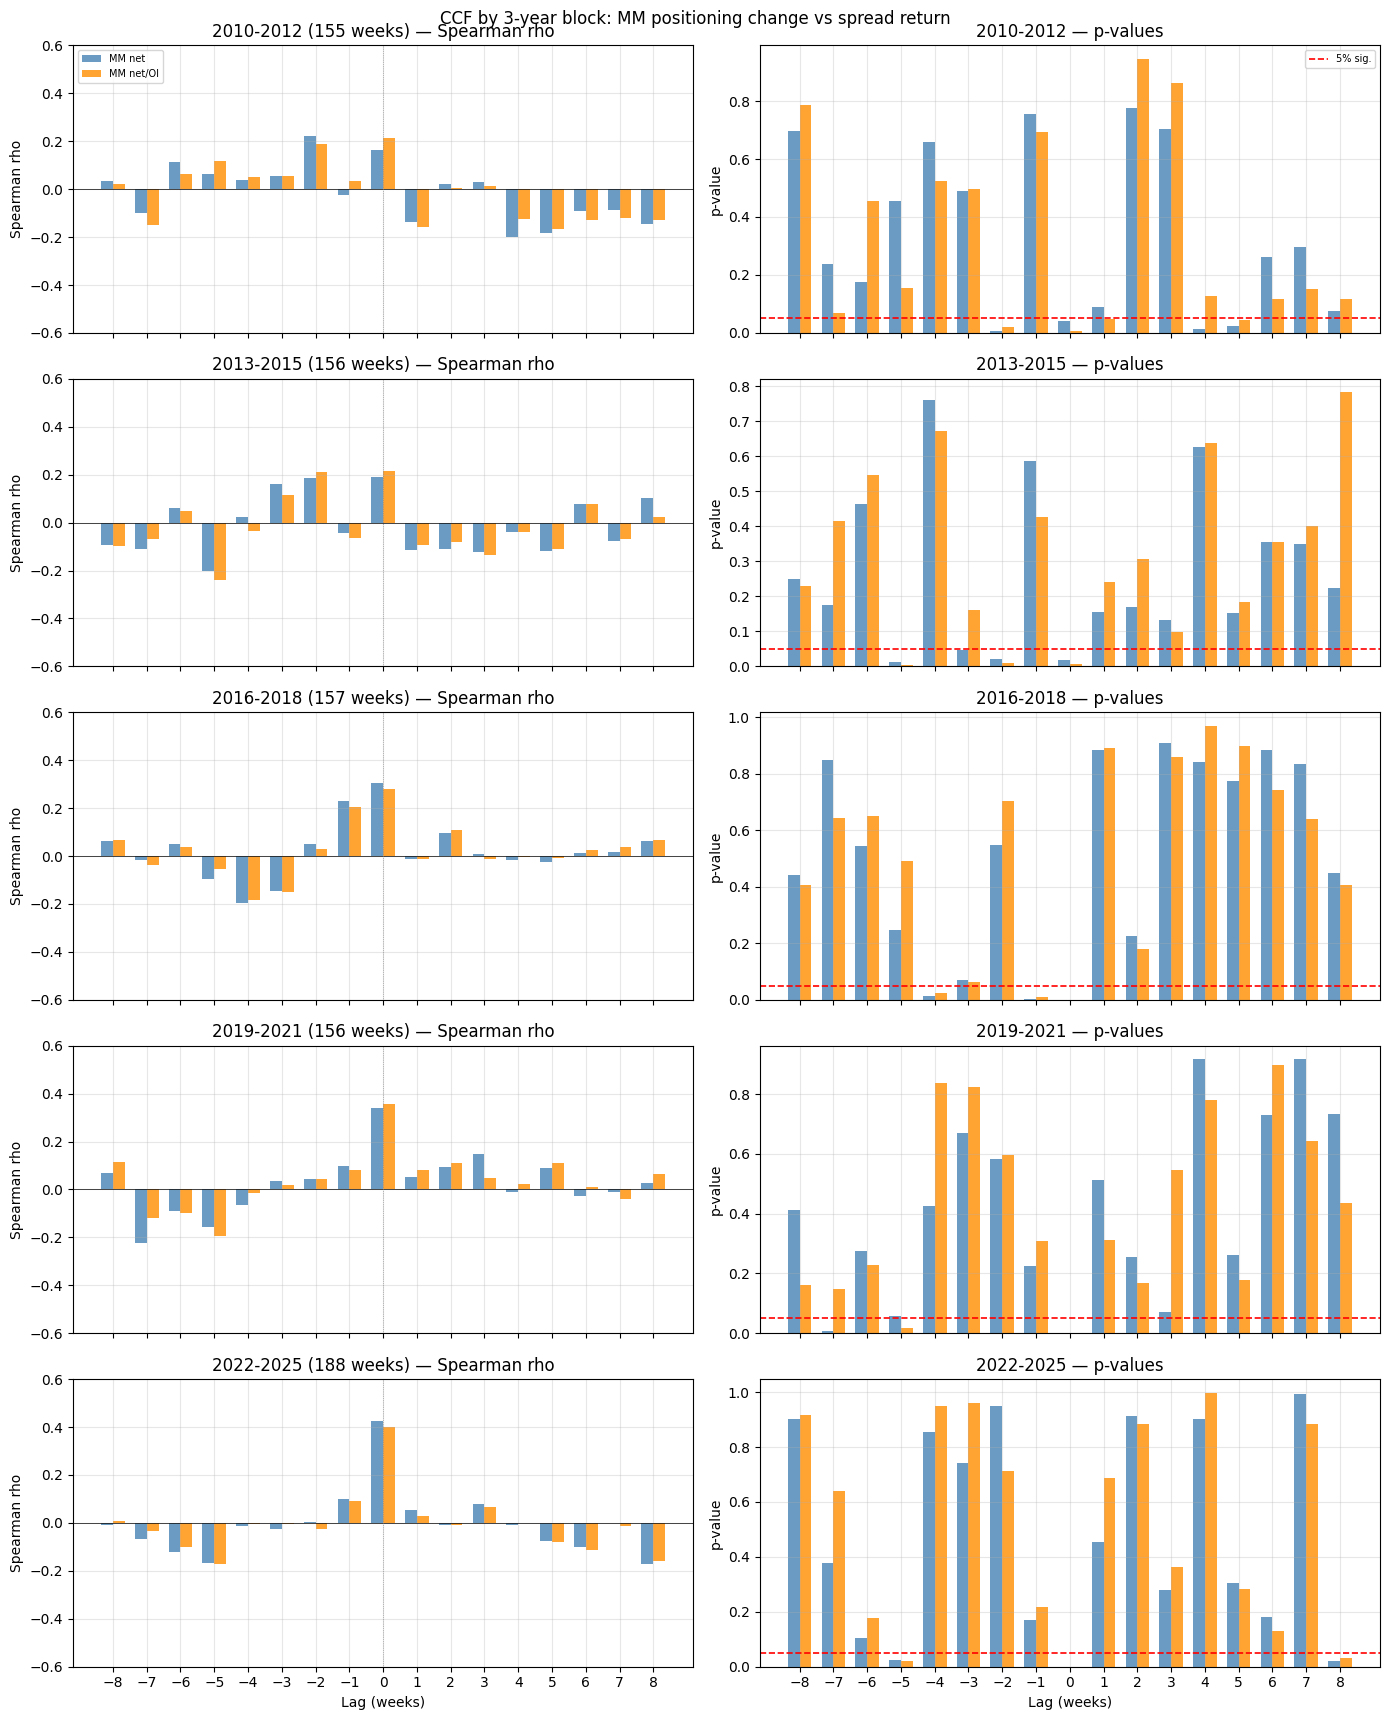

In [10]:
blocks_3y = [
    ('2010-2012', (2010, 2012)),
    ('2013-2015', (2013, 2015)),
    ('2016-2018', (2016, 2018)),
    ('2019-2021', (2019, 2021)),
    ('2022-2025', (2022, 2025)),
]

fig, axes = plt.subplots(len(blocks_3y), 2, figsize=(14, 3.5 * len(blocks_3y)),
                         sharex=True)
bar_width = 0.35

for row, (label, (y_start, y_end)) in enumerate(blocks_3y):
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    mm_oi_b = sub['mm_net_oi_chg'].values
    sp_b = sub['spread_ret'].values

    lags_b, rhos_raw_b, pvals_raw_b = compute_ccf(mm_b, sp_b, MAX_LAG)
    _, rhos_oi_b, pvals_oi_b = compute_ccf(mm_oi_b, sp_b, MAX_LAG)
    x_pos = np.array(lags_b)

    ax = axes[row, 0]
    ax.bar(x_pos - bar_width/2, rhos_raw_b, bar_width,
           color='steelblue', alpha=0.8, label='MM net')
    ax.bar(x_pos + bar_width/2, rhos_oi_b, bar_width,
           color='darkorange', alpha=0.8, label='MM net/OI')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5, linestyle=':')
    ax.set_ylabel('Spearman rho')
    ax.set_title(f'{label} ({len(sub)} weeks) — Spearman rho')
    ax.set_ylim(-0.6, 0.6)
    if row == 0:
        ax.legend(fontsize=7, loc='upper left')

    ax = axes[row, 1]
    ax.bar(x_pos - bar_width/2, pvals_raw_b, bar_width,
           color='steelblue', alpha=0.8)
    ax.bar(x_pos + bar_width/2, pvals_oi_b, bar_width,
           color='darkorange', alpha=0.8)
    ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
    ax.set_ylabel('p-value')
    ax.set_title(f'{label} — p-values')
    ax.set_xticks(lags_b)
    if row == 0:
        ax.legend(fontsize=7)

axes[-1, 0].set_xlabel('Lag (weeks)')
axes[-1, 1].set_xlabel('Lag (weeks)')
plt.suptitle('CCF by 3-year block: WTI MM positioning change vs spread return',
             fontsize=12)
plt.tight_layout()
plt.show()


In [11]:
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_3y + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    sp_b = sub['spread_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                sp_b[k:] if k > 0 else sp_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], sp_b[:len(sp_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()


       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2012   155  +0.224  -0.025  +0.164  -0.137  +0.023
   2013-2015   156  +0.187  -0.044  +0.191  -0.115  -0.111
   2016-2018   157  +0.049  +0.231  +0.305  -0.012  +0.098
   2019-2021   156  +0.044  +0.098  +0.338  +0.053  +0.093
   2022-2025   188  +0.005  +0.101  +0.426  +0.055  -0.008
 Full sample   812  +0.065  +0.069  +0.291  -0.009  +0.023


## 6d. CCF by 2-year blocks

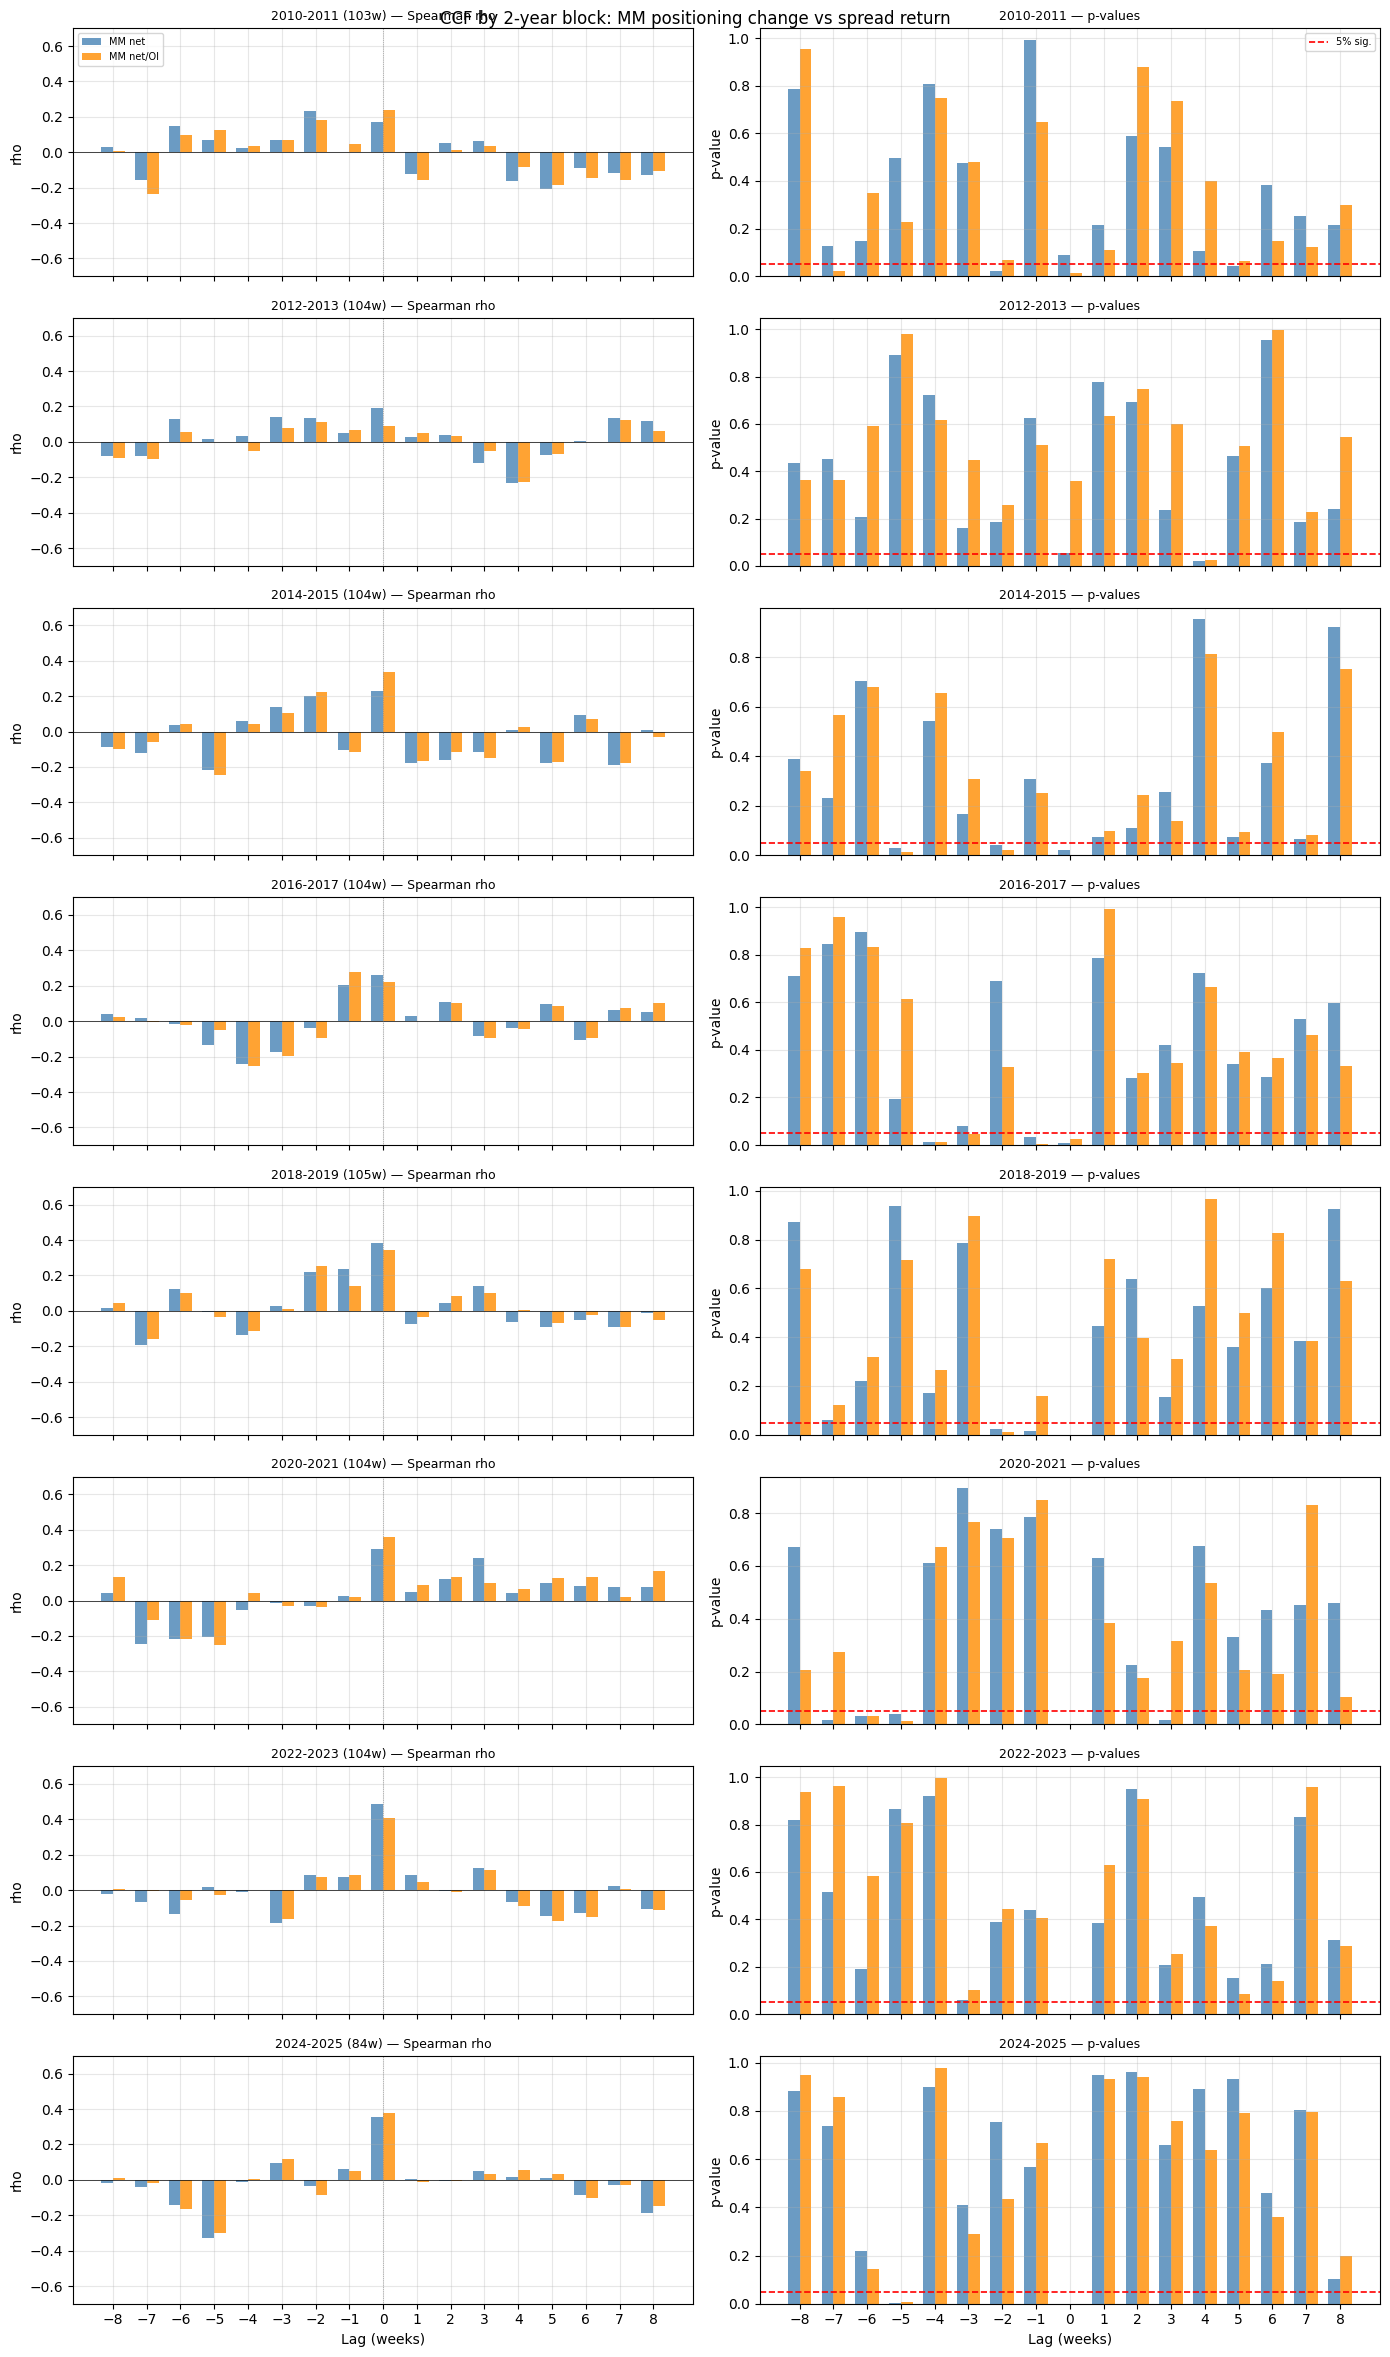

In [12]:
blocks_2y = [
    ('2010-2011', (2010, 2011)),
    ('2012-2013', (2012, 2013)),
    ('2014-2015', (2014, 2015)),
    ('2016-2017', (2016, 2017)),
    ('2018-2019', (2018, 2019)),
    ('2020-2021', (2020, 2021)),
    ('2022-2023', (2022, 2023)),
    ('2024-2025', (2024, 2025)),
]

fig, axes = plt.subplots(len(blocks_2y), 2, figsize=(14, 3 * len(blocks_2y)),
                         sharex=True)
bar_width = 0.35

for row, (label, (y_start, y_end)) in enumerate(blocks_2y):
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    mm_oi_b = sub['mm_net_oi_chg'].values
    sp_b = sub['spread_ret'].values

    lags_b, rhos_raw_b, pvals_raw_b = compute_ccf(mm_b, sp_b, MAX_LAG)
    _, rhos_oi_b, pvals_oi_b = compute_ccf(mm_oi_b, sp_b, MAX_LAG)
    x_pos = np.array(lags_b)

    ax = axes[row, 0]
    ax.bar(x_pos - bar_width/2, rhos_raw_b, bar_width,
           color='steelblue', alpha=0.8, label='MM net')
    ax.bar(x_pos + bar_width/2, rhos_oi_b, bar_width,
           color='darkorange', alpha=0.8, label='MM net/OI')
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='grey', lw=0.5, linestyle=':')
    ax.set_ylabel('rho')
    ax.set_title(f'{label} ({len(sub)}w) — Spearman rho', fontsize=9)
    ax.set_ylim(-0.7, 0.7)
    if row == 0:
        ax.legend(fontsize=7, loc='upper left')

    ax = axes[row, 1]
    ax.bar(x_pos - bar_width/2, pvals_raw_b, bar_width,
           color='steelblue', alpha=0.8)
    ax.bar(x_pos + bar_width/2, pvals_oi_b, bar_width,
           color='darkorange', alpha=0.8)
    ax.axhline(0.05, color='red', linestyle='--', lw=1.2, label='5% sig.')
    ax.set_ylabel('p-value')
    ax.set_title(f'{label} — p-values', fontsize=9)
    ax.set_xticks(lags_b)
    if row == 0:
        ax.legend(fontsize=7)

axes[-1, 0].set_xlabel('Lag (weeks)')
axes[-1, 1].set_xlabel('Lag (weeks)')
plt.suptitle('CCF by 2-year block: WTI MM positioning change vs spread return',
             fontsize=12)
plt.tight_layout()
plt.show()


In [13]:
KEY = [-2, -1, 0, 1, 2]
print(f'{"Block":>12s}  {"n":>4s}', end='')
for k in KEY:
    print(f'  lag {k:+d}', end='')
print()
print('-' * (22 + 9 * len(KEY)))

for label, (y_start, y_end) in blocks_2y + [('Full sample', (2010, 2025))]:
    sub = df[(df['year'] >= y_start) & (df['year'] <= y_end)]
    mm_b = sub['mm_net_chg'].values
    sp_b = sub['spread_ret'].values
    print(f'{label:>12s}  {len(sub):>4d}', end='')
    for k in KEY:
        if k >= 0:
            rho, _ = sp_stats.spearmanr(
                mm_b[:len(mm_b)-k] if k > 0 else mm_b,
                sp_b[k:] if k > 0 else sp_b)
        else:
            rho, _ = sp_stats.spearmanr(mm_b[-k:], sp_b[:len(sp_b)+k])
        print(f'  {rho:+.3f}', end='')
    print()


       Block     n  lag -2  lag -1  lag +0  lag +1  lag +2
-------------------------------------------------------------------
   2010-2011   103  +0.231  +0.001  +0.169  -0.124  +0.054
   2012-2013   104  +0.133  +0.049  +0.190  +0.028  +0.040
   2014-2015   104  +0.203  -0.102  +0.227  -0.178  -0.159
   2016-2017   104  -0.040  +0.207  +0.260  +0.027  +0.108
   2018-2019   105  +0.222  +0.235  +0.384  -0.076  +0.047
   2020-2021   104  -0.033  +0.027  +0.289  +0.048  +0.121
   2022-2023   104  +0.086  +0.077  +0.489  +0.087  -0.006
   2024-2025    84  -0.035  +0.064  +0.356  +0.007  -0.005
 Full sample   812  +0.065  +0.069  +0.291  -0.009  +0.023


## 7. Rolling stability of key lags

Are the lead/lag relationships stable over time? Compute the
lag -1, 0, +1 correlations on a rolling 104-week (2-year) window.

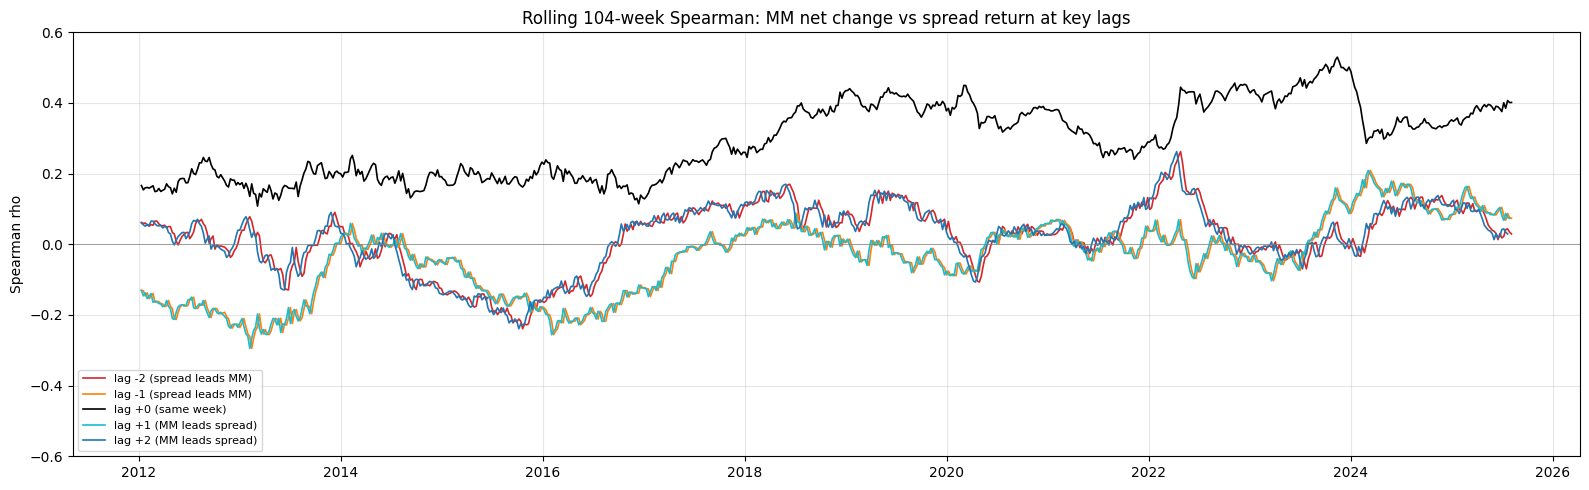

In [14]:
WINDOW = 104  # 2 years
KEY_LAGS = [-2, -1, 0, 1, 2]

rolling_results = {}
for k in KEY_LAGS:
    if k >= 0:
        x, y = mm_vals[:len(mm_vals)-max(k,1)], spread_vals[max(k,1):] if k > 0 else spread_vals
    # Simpler: just shift the series
    mm_s = pd.Series(mm_vals)
    pr_s = pd.Series(spread_vals)
    if k >= 0:
        # MM at t vs price at t+k
        aligned_mm = mm_s.iloc[:len(mm_s)-k] if k > 0 else mm_s
        aligned_pr = pr_s.shift(-k).iloc[:len(pr_s)-k] if k > 0 else pr_s
    else:
        # price at t vs MM at t+|k| → equivalently MM.shift(k) vs price
        aligned_mm = mm_s.shift(-k)  # shift forward by |k|
        aligned_pr = pr_s

    rhos = []
    for i in range(len(aligned_mm)):
        if i < WINDOW:
            rhos.append(np.nan)
            continue
        m_win = aligned_mm.iloc[i-WINDOW:i].values
        p_win = aligned_pr.iloc[i-WINDOW:i].values
        mask = ~(np.isnan(m_win) | np.isnan(p_win))
        if mask.sum() < 20:
            rhos.append(np.nan)
        else:
            rhos.append(sp_stats.spearmanr(m_win[mask], p_win[mask]).statistic)
    rolling_results[k] = rhos[:len(df)]

fig, ax = plt.subplots(figsize=(16, 5))
lag_colors = {-2: 'tab:red', -1: 'tab:orange', 0: 'black', 1: 'tab:cyan', 2: 'tab:blue'}
for k in KEY_LAGS:
    label = f'lag {k:+d}' + (' (spread leads MM)' if k < 0 else ' (MM leads spread)' if k > 0 else ' (same week)')
    vals = rolling_results[k]
    ax.plot(df['as_of_date'].iloc[:len(vals)], vals,
            label=label, color=lag_colors[k], lw=1.2)

ax.axhline(0, color='grey', lw=0.5)
ax.set_title(f'Rolling {WINDOW}-week Spearman: WTI MM net change vs spread return at key lags')
ax.set_ylabel('Spearman rho')
ax.set_ylim(-0.6, 0.6)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

## 8. By regime: trending vs mean-reverting

Split by the sign of the 26-week trailing spread return.
Does the MM/price relationship differ in bull vs bear markets?

In [15]:
# 26-week trailing return
df['trailing_26w_spread_ret'] = df['F1MinusF2_RolledPrice'].pct_change(26) * 100
df['regime'] = np.where(df['trailing_26w_spread_ret'] > 0, 'Bull', 'Bear')

regime_mask = df['trailing_26w_spread_ret'].notna()
print(f'Regime breakdown:')
print(df.loc[regime_mask, 'regime'].value_counts())
print()

# CCF by regime
for regime in ['Bull', 'Bear']:
    sub = df[regime_mask & (df['regime'] == regime)]
    mm_r = sub['mm_net_chg'].values
    pr_r = sub['spread_ret'].values

    print(f'\n{regime} regime ({len(sub)} weeks):')
    print(f'{"Lag":>4s}  {"rho":>8s}  Interpretation')
    for k in range(-4, 5):
        if k >= 0:
            rho, _ = sp_stats.spearmanr(mm_r[:len(mm_r)-k] if k > 0 else mm_r,
                                         pr_r[k:] if k > 0 else pr_r)
        else:
            rho, _ = sp_stats.spearmanr(mm_r[-k:], pr_r[:len(pr_r)+k])
        interp = 'spread leads' if k < 0 else ('same week' if k == 0 else 'MM leads')
        print(f'{k:>4d}  {rho:>+8.3f}  {interp}')

Regime breakdown:
regime
Bear    544
Bull    242
Name: count, dtype: int64


Bull regime (242 weeks):
 Lag       rho  Interpretation
  -4    -0.121  spread leads
  -3    +0.110  spread leads
  -2    +0.043  spread leads
  -1    +0.077  spread leads
   0    +0.325  same week
   1    +0.070  MM leads
   2    +0.006  MM leads
   3    +0.066  MM leads
   4    -0.051  MM leads

Bear regime (544 weeks):
 Lag       rho  Interpretation
  -4    -0.021  spread leads
  -3    -0.034  spread leads
  -2    +0.031  spread leads
  -1    +0.069  spread leads
   0    +0.278  same week
   1    -0.013  MM leads
   2    -0.009  MM leads
   3    +0.054  MM leads
   4    -0.012  MM leads
